# ANOVA con Seaborn ≥ 0.14 (sin warnings)

Este notebook:
- Carga un CSV desde Google Colab (upload).
- Ejecuta ANOVA (Grado y Sujeto → Salario) con `statsmodels`.
- Genera visualizaciones compatibles con **Seaborn 0.14+**.


In [2]:
# Instalación de librerías (Seaborn 0.14+)
!pip install -q -U pandas statsmodels matplotlib "seaborn>=0.14"


ERROR: Could not find a version that satisfies the requirement seaborn>=0.14 (from versions: 0.1, 0.2.0, 0.2.1, 0.3, 0.3.1, 0.4.0, 0.5.0, 0.5.1, 0.6.0, 0.7.0, 0.7.1, 0.8, 0.8.1, 0.9.0, 0.9.1rc0, 0.9.1, 0.10.0rc0, 0.10.0, 0.10.1, 0.11.0rc0, 0.11.0, 0.11.1, 0.11.2rc0, 0.11.2, 0.12.0b0, 0.12.0b1, 0.12.0b2, 0.12.0b3, 0.12.0rc0, 0.12.0, 0.12.1, 0.12.2, 0.13.0rc0, 0.13.0, 0.13.1, 0.13.2)
ERROR: No matching distribution found for seaborn>=0.14


In [3]:
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


## Cargar datos (CSV)

In [4]:
from google.colab import files
uploaded = files.upload()

file_name = next(iter(uploaded.keys()))
df = pd.read_csv(file_name, encoding="utf-16")

display(df.head())
df.info()


Saving SalariosAcadémicos.csv to SalariosAcadémicos.csv


,Sujeto,Grado,Salario
0,1,1,1.7
1,1,1,1.9
2,1,2,1.8
3,1,2,2.1
4,1,3,2.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Sujeto   45 non-null     int64  
 1   Grado    45 non-null     int64  
 2   Salario  45 non-null     float64
dtypes: float64(1), int64(2)
memory usage: 1.2 KB


## Preparación de variables

In [5]:
df["Grado"] = df["Grado"].astype("category")
df["Sujeto"] = df["Sujeto"].astype("category")

df[["Grado","Sujeto","Salario"]].head()


,Grado,Sujeto,Salario
0,1,1,1.7
1,1,1,1.9
2,2,1,1.8
3,2,1,2.1
4,3,1,2.5


## ANOVA

In [6]:
anova_model = smf.ols("Salario ~ C(Grado) + C(Sujeto)", data=df).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)

print("Resultados del ANOVA:")
display(anova_table)


Resultados del ANOVA:


,sum_sq,df,F,PR(>F)
C(Grado),8.382452,2.0,214.391872,9.117586e-22
C(Sujeto),5.979253,3.0,101.951330,1.670477e-18
Residual,0.762425,39.0,NaN,NaN


## Visualizaciones (Seaborn ≥ 0.14)

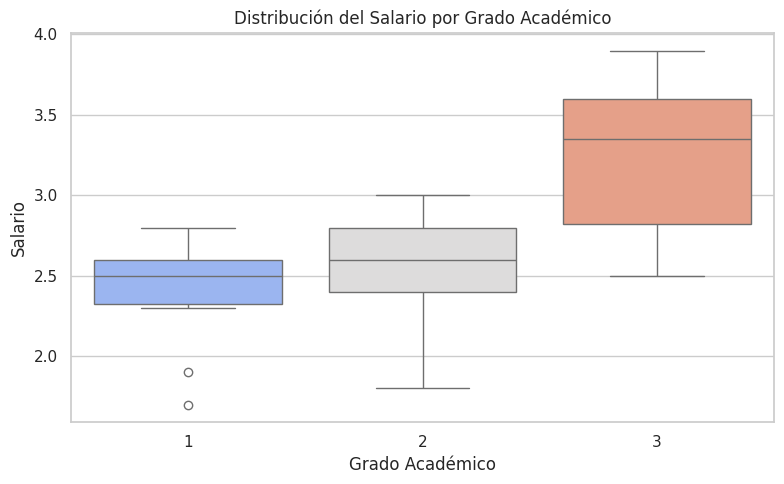

In [7]:
# Boxplot: Salario por Grado
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Grado",
    y="Salario",
    hue="Grado",          # requerido si usas palette en seaborn >= 0.14
    palette="coolwarm",
    legend=False,
    ax=ax
)
ax.set_xlabel("Grado Académico")
ax.set_ylabel("Salario")
ax.set_title("Distribución del Salario por Grado Académico")
plt.tight_layout()
plt.show()


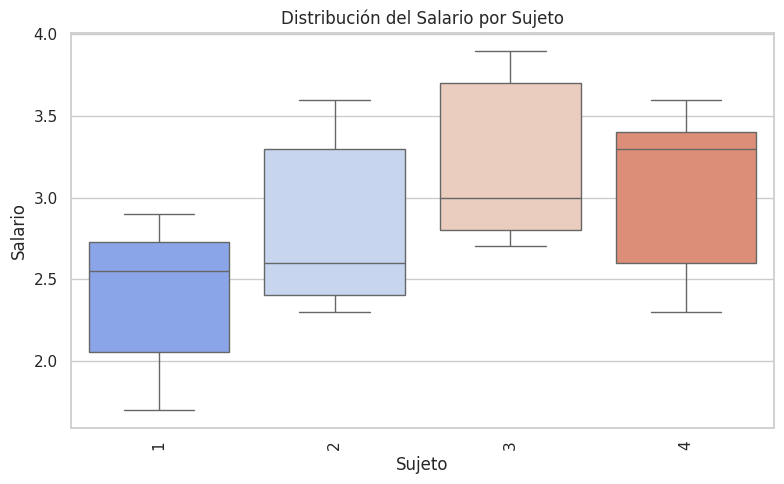

In [8]:
# Boxplot: Salario por Sujeto
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Sujeto",
    y="Salario",
    hue="Sujeto",
    palette="coolwarm",
    legend=False,
    ax=ax
)
ax.set_xlabel("Sujeto")
ax.set_ylabel("Salario")
ax.set_title("Distribución del Salario por Sujeto")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


## Supuestos del modelo

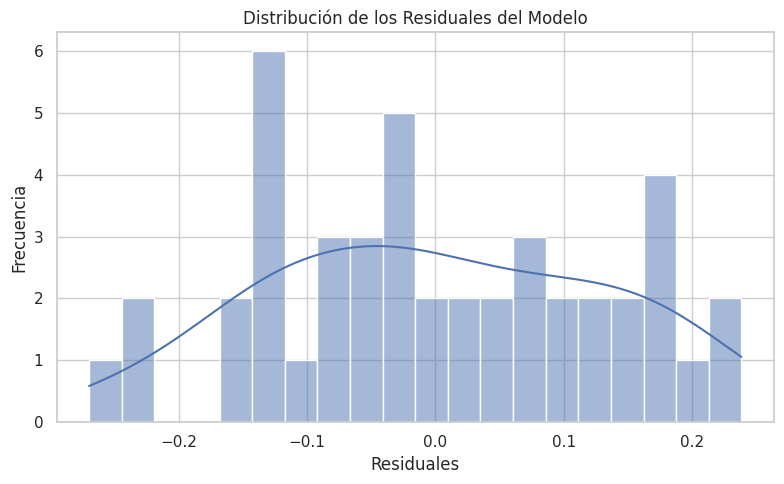

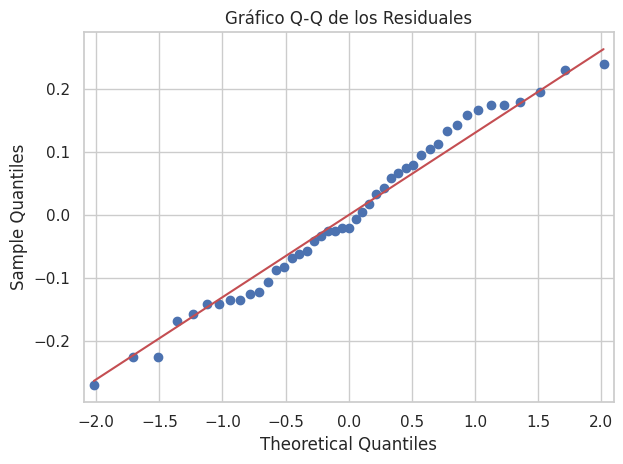

In [9]:
residuals = anova_model.resid

# Histograma de residuales
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(residuals, bins=20, kde=True, ax=ax)
ax.set_xlabel("Residuales")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de los Residuales del Modelo")
plt.tight_layout()
plt.show()

# Q-Q plot
sm.qqplot(residuals, line="s")
plt.title("Gráfico Q-Q de los Residuales")
plt.tight_layout()
plt.show()


## Efectos principales

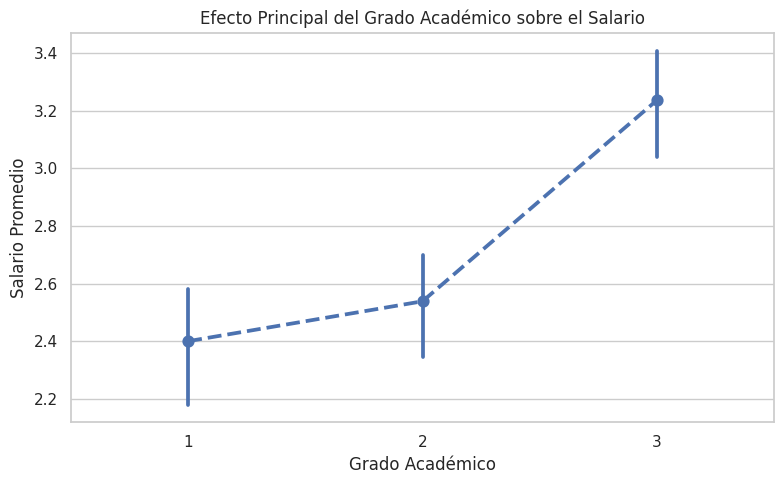

In [10]:
# Efecto principal de Grado (Seaborn 0.14+: usar errorbar en lugar de ci)
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(
    data=df,
    x="Grado",
    y="Salario",
    errorbar=("ci", 95),
    markers="o",
    linestyles="--",
    ax=ax
)
ax.set_xlabel("Grado Académico")
ax.set_ylabel("Salario Promedio")
ax.set_title("Efecto Principal del Grado Académico sobre el Salario")
plt.tight_layout()
plt.show()


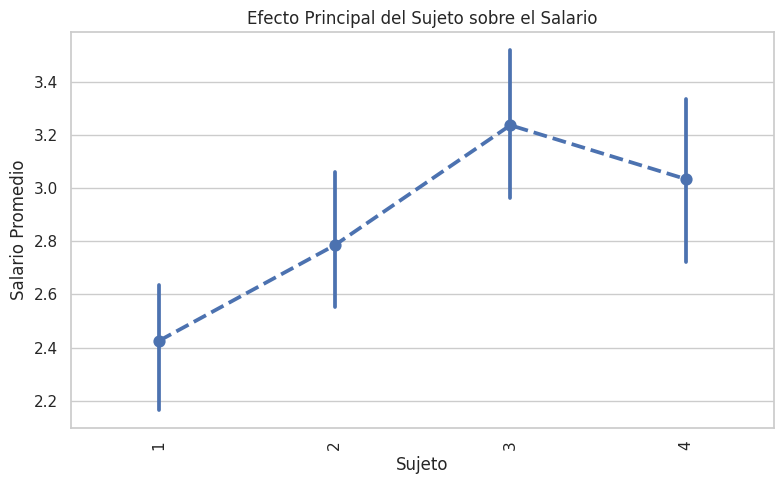

In [11]:
# Efecto principal de Sujeto
fig, ax = plt.subplots(figsize=(8, 5))
sns.pointplot(
    data=df,
    x="Sujeto",
    y="Salario",
    errorbar=("ci", 95),
    markers="o",
    linestyles="--",
    ax=ax
)
ax.set_xlabel("Sujeto")
ax.set_ylabel("Salario Promedio")
ax.set_title("Efecto Principal del Sujeto sobre el Salario")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()
